In [1]:
#Data Manipulation and Visualization 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading Dataset
df = pd.read_csv("german_credit_data.csv")

In [3]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
df.drop(columns='Unnamed: 0', inplace=True)

In [5]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [6]:
# Checking the number of missing values in each column
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [7]:
#Checking for any duplicaate values
df.duplicated().sum()

np.int64(0)

In [8]:
# Dropping rows with missing values in the 'Checking account' column because if a customer does not have a checking account, 
# this feature does not provide useful information for the current analysis.
df.dropna(subset=['Checking account'],inplace=True)

In [9]:
#Filling the missing values
df['Saving accounts'] = df['Saving accounts'].fillna('No Info')

In [10]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,No Info,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
7,35,male,3,rent,little,moderate,6948,36,car,good


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 606 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               606 non-null    int64 
 1   Sex               606 non-null    object
 2   Job               606 non-null    int64 
 3   Housing           606 non-null    object
 4   Saving accounts   606 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     606 non-null    int64 
 7   Duration          606 non-null    int64 
 8   Purpose           606 non-null    object
 9   Risk              606 non-null    object
dtypes: int64(4), object(6)
memory usage: 52.1+ KB


In [12]:
df.describe()

,Age,Job,Credit amount,Duration
count,606.000000,606.000000,606.000000,606.000000
mean,34.973597,1.876238,3361.082508,21.519802
std,11.684105,0.692006,2983.045726,12.491667
min,19.000000,0.000000,276.000000,4.000000
25%,26.000000,2.000000,1331.500000,12.000000
50%,32.000000,2.000000,2342.500000,18.000000
75%,41.000000,2.000000,4096.750000,26.750000
max,75.000000,3.000000,18424.000000,72.000000


In [13]:
Numerical_col = ['Age','Credit amount','Duration']

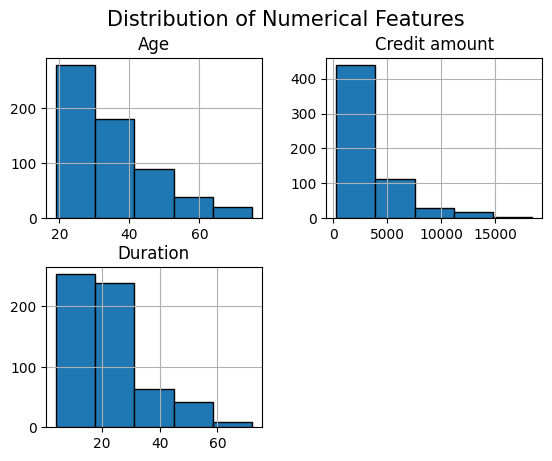

In [14]:
# Distribution of Numerical Features
df[Numerical_col].hist(bins=5,edgecolor='black')
plt.suptitle('Distribution of Numerical Features',fontsize=15)
plt.show()

**Observations**
1. The applicant distribution is high in the age group 20-30.
2. The above Distribution indicates that a large number of applicants request for mid-range credit values(between 1000 - 5000 units).
3. The Distribution shows that the majority of applicants opt for loan duration in the range 20-30 months.

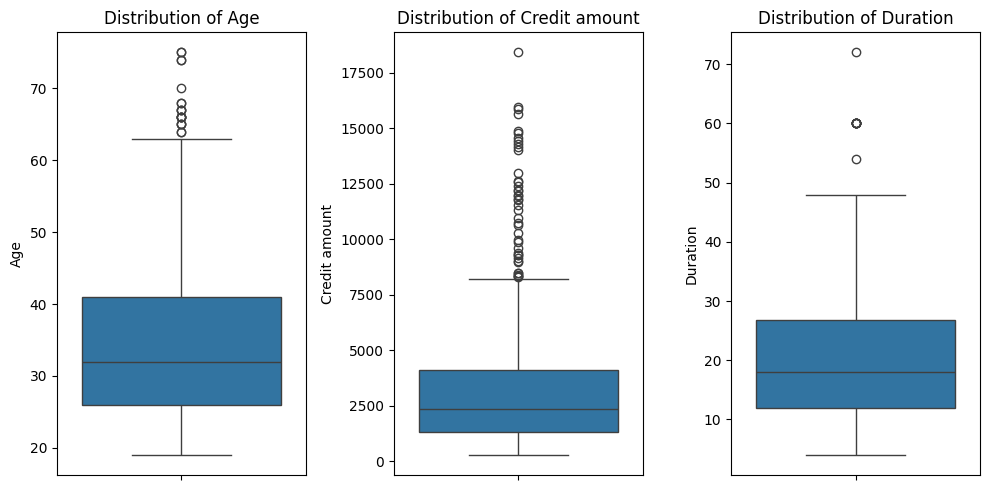

In [15]:
#Checking for Outliers
plt.figure(figsize=(10,5))
for i, col in enumerate(['Age','Credit amount','Duration']):
    plt.subplot(1,3,i+1)
    sns.boxplot(y = df[col])
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [16]:
categorical_col = ['Sex','Job','Housing','Saving accounts','Checking account','Purpose']

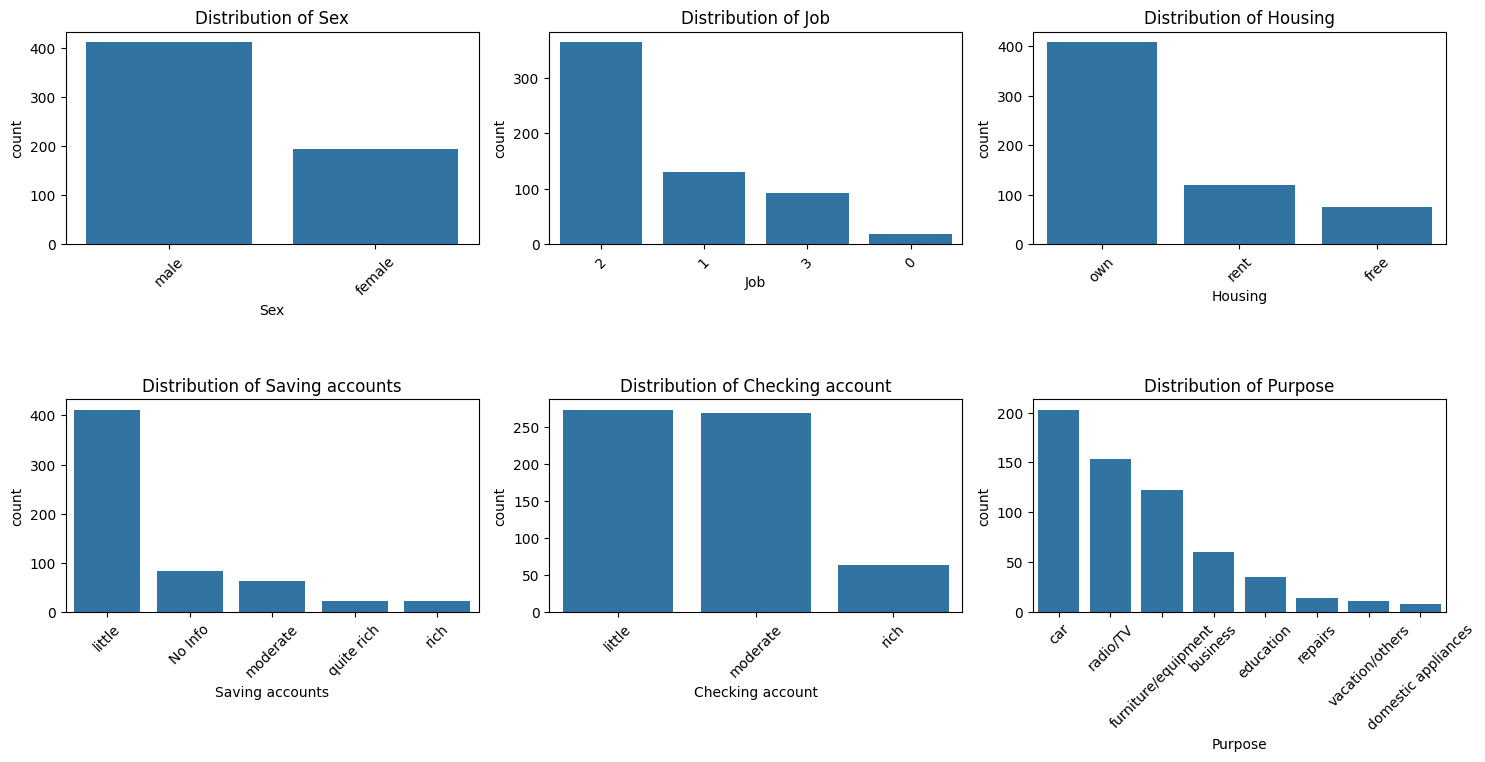

In [17]:
# Distribution of Categorical Features
plt.figure(figsize=(15,10))
for i,col in enumerate(categorical_col):
    plt.subplot(3,3,i+1)
    sns.countplot(data = df, x = col, order = df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [18]:
df["Risk"].value_counts(normalize=True) * 100

Risk
good    58.085809
bad     41.914191
Name: proportion, dtype: float64

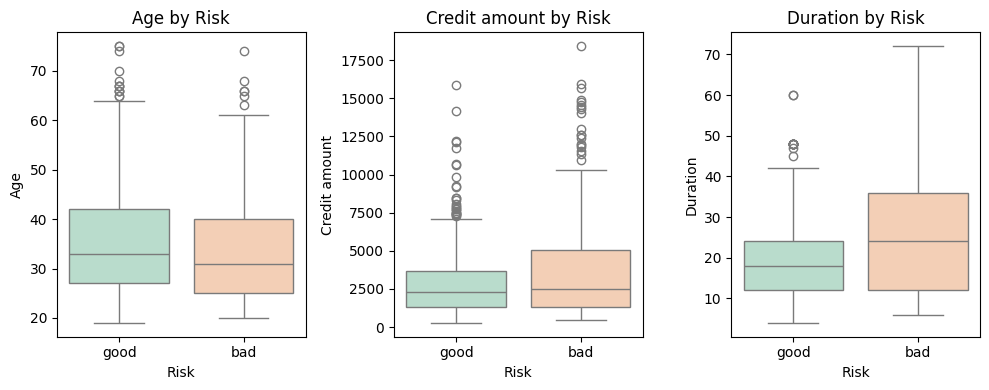

In [19]:
#Analyzing the Risk Factor
plt.figure(figsize=(10,4))
for i,col in enumerate(Numerical_col):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df, x='Risk',y=col,hue='Risk',palette="Pastel2")
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [20]:
df.groupby('Risk')[Numerical_col].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.066929,3874.984252,25.137795
good,35.627841,2990.255682,18.909091


**Risk level appears independent of the applicant’s age. However, higher credit amounts and longer loan durations are associated with an increased risk factor.**

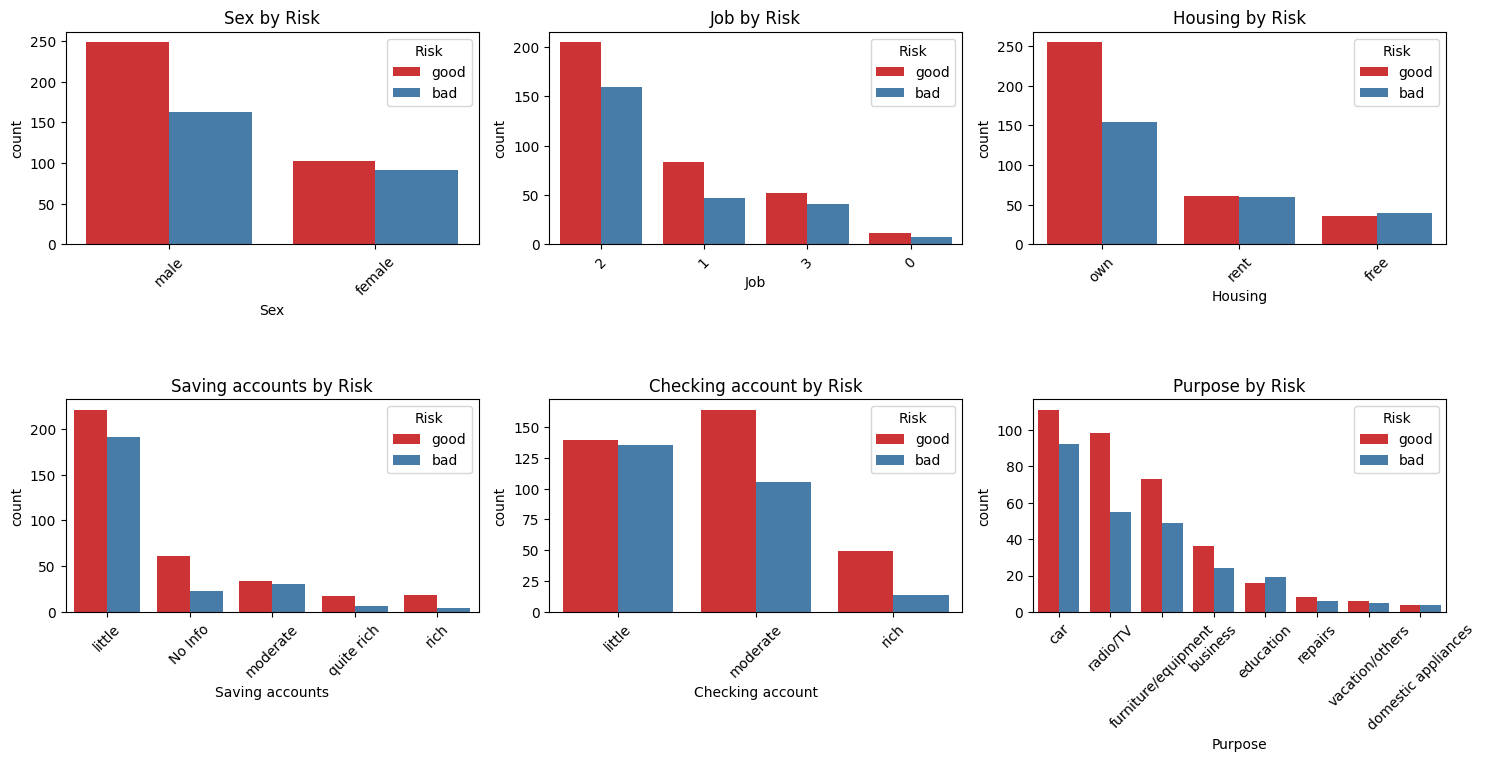

In [21]:
plt.figure(figsize=(15,10))
for i, col in enumerate(categorical_col):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df,x=col,hue='Risk',palette='Set1',order = df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#**Preparing the dataset for feature engineering**

In [22]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [23]:
features = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration']

In [24]:
target = 'Risk'

In [25]:
df_model = df[features+[target]].copy()

In [26]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,67,male,2,own,No Info,little,1169,6,good
1,22,female,2,own,little,moderate,5951,48,bad
3,45,male,2,free,little,little,7882,42,good
4,53,male,2,free,little,little,4870,24,bad
7,35,male,3,rent,little,moderate,6948,36,good


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
import joblib

In [28]:
cat_cols = df_model.select_dtypes(include='object').columns.drop('Risk')

In [29]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [30]:
le_dict = {}

In [31]:
for col in cat_cols:
    oe = OrdinalEncoder()
    df_model[col] = oe.fit_transform(df_model[[col]]) 
    le_dict[col] = oe
    joblib.dump(oe, f"{col}_encoder.pkl")

In [32]:
oe_target = OrdinalEncoder()

In [33]:
df_model[target] = oe_target.fit_transform(df_model[[target]])

In [34]:
df_model[target].value_counts()

Risk
1.0    352
0.0    254
Name: count, dtype: int64

**1 is Good (Lower risk) and 0 is Bad (Higher risk)**

In [35]:
joblib.dump(oe_target, "target_encoder.pkl")

['target_encoder.pkl']

In [36]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,67,1.0,2,1.0,0.0,0.0,1169,6,1.0
1,22,0.0,2,1.0,1.0,1.0,5951,48,0.0
3,45,1.0,2,0.0,1.0,0.0,7882,42,1.0
4,53,1.0,2,0.0,1.0,0.0,4870,24,0.0
7,35,1.0,3,2.0,1.0,1.0,6948,36,1.0


In [37]:
#Create Independent and Dependent features
X = df_model.drop(target, axis=1)
y = df_model[target]

In [38]:
X.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,67,1.0,2,1.0,0.0,0.0,1169,6
1,22,0.0,2,1.0,1.0,1.0,5951,48
3,45,1.0,2,0.0,1.0,0.0,7882,42
4,53,1.0,2,0.0,1.0,0.0,4870,24
7,35,1.0,3,2.0,1.0,1.0,6948,36


In [39]:
y.head()

0    1.0
1    0.0
3    1.0
4    0.0
7    1.0
Name: Risk, dtype: float64

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1,stratify=y)

In [42]:
X_train.shape

(484, 8)

In [43]:
X_test.shape

(122, 8)

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [45]:
def train_model(model, param_grid, X_train,y_train,X_test,y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring='roc_auc',n_jobs=-1)
    grid.fit(X_train,y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:,1]
    acc = accuracy_score(y_test,y_pred)
    return best_model, acc, grid.best_params_,y_pred,y_proba

In [46]:
#Model Evaluation Metrics
from sklearn.metrics import precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix

def eval_metrics(y_test, y_pred,y_proba):
    prec = precision_score(y_test,y_pred)
    rec = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    roc_auc = roc_auc_score(y_test,y_proba)
    return prec, rec, f1, roc_auc

**#Decision Tree Model**

In [47]:
dt = DecisionTreeClassifier(random_state=1, class_weight="balanced")
dt_params = {
    "max_depth" : [3,5,7,10,None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,4]
}

In [48]:
best_dt, acc_dt, params_dt,y_pred_dt,y_proba_dt = train_model(dt, dt_params, X_train,y_train,X_test,y_test)
prec_dt, rec_dt, f1_dt,roc_auc_dt = eval_metrics(y_test,y_pred_dt,y_proba_dt)

In [49]:
print(f" Decision Tree Parameters: {params_dt}")

 Decision Tree Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [50]:
print(f"Decision Tree Metrics:\nAccuracy: {acc_dt}\nPrecision score: {prec_dt}\nRecall score: {rec_dt}\nF1 score: {f1_dt}\nROC_AUC score: {roc_auc_dt}")

Decision Tree Metrics:
Accuracy: 0.6147540983606558
Precision score: 0.6818181818181818
Recall score: 0.6338028169014085
F1 score: 0.656934306569343
ROC_AUC score: 0.6186136426401547


**#Random Forest Classifier**

In [51]:
rf = RandomForestClassifier(random_state=1,class_weight="balanced",n_jobs=-1)
rf_params = {
    "n_estimators" : [100,200],
    "max_depth" : [5,7,10,None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,4]
}

In [52]:
best_rf, acc_rf, params_rf,y_pred_rf,y_proba_rf = train_model(rf, rf_params, X_train,y_train,X_test,y_test)
prec_rf, rec_rf, f1_rf,roc_auc_rf = eval_metrics(y_test,y_pred_rf,y_proba_rf)

In [53]:
print(f"Best Random Forest Parameters: {params_rf}")

Best Random Forest Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}


In [54]:
print(f"Random Forest Metrics:\nAccuracy: {acc_rf}\nPrecision score: {prec_rf}\nRecall score: {rec_rf}\nF1 score: {f1_rf}\nROC_AUC score: {roc_auc_rf}")

Random Forest Metrics:
Accuracy: 0.639344262295082
Precision score: 0.684931506849315
Recall score: 0.704225352112676
F1 score: 0.6944444444444444
ROC_AUC score: 0.659762496547915


**#Extra Trees Classifier**

In [55]:
et = ExtraTreesClassifier(random_state=1,class_weight="balanced",n_jobs=-1)
et_params = {
    "n_estimators" : [100,200],
    "max_depth" : [5,7,10,None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,4]
}

In [56]:
best_et, acc_et, params_et,y_pred_et,y_proba_et = train_model(et, et_params, X_train,y_train,X_test,y_test)
prec_et, rec_et, f1_et,roc_auc_et = eval_metrics(y_test,y_pred_et,y_proba_et)

In [57]:
print(f"Best Extra Trees Parameters: {params_et}")

Best Extra Trees Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}


In [58]:
print(f"Extra Trees Metrics:\nAccuracy: {acc_et}\nPrecision score: {prec_et}\nRecall score: {rec_et}\nF1 score: {f1_et}\nROC_AUC score: {roc_auc_et}")

Extra Trees Metrics:
Accuracy: 0.6475409836065574
Precision score: 0.7333333333333333
Recall score: 0.6197183098591549
F1 score: 0.6717557251908397
ROC_AUC score: 0.6906931786799226


**#XGBoost Classifier**

In [59]:
xg = XGBClassifier(random_state=1, scale_pos_weight= (y_train==0).sum() / (y_train==1).sum(), eval_metric = "logloss" )

In [60]:
xgb_params = {
    "n_estimators" : [100,200],
    "max_depth" : [5,7,10],
    "learning_rate" : [0.01,0.1,0.2],
    "subsample" : [0.7,1],
    "colsample_bytree" : [0.7,1]
}

In [61]:
best_xgb, acc_xgb, params_xgb,y_pred_xgb,y_proba_xgb = train_model(xg, xgb_params, X_train,y_train,X_test,y_test)
prec_xgb, rec_xgb, f1_xgb,roc_auc_xgb = eval_metrics(y_test,y_pred_xgb,y_proba_xgb)

In [62]:
print(f"XGBoost Parameters: {params_xgb}")

XGBoost Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1}


In [63]:
print(f"XGBoost Classifier Metrics:\nAccuracy: {acc_xgb}\nPrecision score: {prec_xgb}\nRecall score: {rec_xgb}\nF1 score: {f1_xgb}\nROC_AUC score: {roc_auc_xgb}")

XGBoost Classifier Metrics:
Accuracy: 0.5983606557377049
Precision score: 0.6617647058823529
Recall score: 0.6338028169014085
F1 score: 0.6474820143884892
ROC_AUC score: 0.652029826014913


**#Model Comparison Table**

In [64]:
results = pd.DataFrame({
    'Model': ['Decision Tree ', 'Random Forest', 'Extra Trees', 'XGBoost'],
    'Accuracy': [acc_dt, acc_rf, acc_et, acc_xgb],
    'ROC-AUC': [roc_auc_dt, roc_auc_rf, roc_auc_et, roc_auc_xgb],
    'F1-score': [f1_dt, f1_rf, f1_et, f1_xgb]
}).sort_values('ROC-AUC', ascending=False)
results

,Model,Accuracy,ROC-AUC,F1-score
2,Extra Trees,0.647541,0.690693,0.671756
1,Random Forest,0.639344,0.659762,0.694444
3,XGBoost,0.598361,0.652030,0.647482
0,Decision Tree,0.614754,0.618614,0.656934


**From the above table we can conclude that Extra Trees model is the best fit model**

In [65]:
#Exporting the best model
joblib.dump(best_et,"extra_trees_model.pkl")

['extra_trees_model.pkl']

# CONCLUSION
Among all the models evaluated, Extra Trees Classifier consistently delivered higher accuracy.

Based on its high score, I selected **Extra Tress Classifer as the final model for this project**.

**---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------**

### Experiment with Neural Network (Benchmarking Only)

To check whether a non-linear deep model performs better on this tabular financial dataset, 
I experimented with a simple Neural Network (MLPClassifier). 

Neural networks often do not outperform tree-based models on low-dimensional structured data, 
but including this step helps benchmark performance and validate model choice.

As expected, the NN achieved lower metrics compared to tree models, so it was **not selected** 
as the final model for risk prediction.


In [66]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

In [67]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [68]:
mlp = MLPClassifier( hidden_layer_sizes=(32,16), solver="lbfgs", max_iter=300, random_state=30 )
mlp.fit(X_train_sc,y_train)

,hidden_layer_sizes,"(32, ...)"
,activation,'relu'
,solver,'lbfgs'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,300
,shuffle,True
,random_state,30


In [69]:
y_pred_nn = mlp.predict(X_test_sc)
y_proba_nn = mlp.predict_proba(X_test_sc)[:,1]

In [70]:
prec_nn, rec_nn, f1_nn,roc_auc_nn = eval_metrics(y_test,y_pred_nn,y_proba_nn)
acc_nn = accuracy_score(y_test,y_pred_nn)

In [71]:
print(f"MLPClassifier Metrics:\nAccuracy: {acc_nn}\nPrecision score: {prec_nn}\nRecall score: {rec_nn}\nF1 score: {f1_nn}\nROC_AUC score: {roc_auc_nn}")

MLPClassifier Metrics:
Accuracy: 0.5573770491803278
Precision score: 0.6491228070175439
Recall score: 0.5211267605633803
F1 score: 0.578125
ROC_AUC score: 0.5926539629936483
